# Predicting 30-Day Extreme Forward Return Events in NVIDIA Stock
## XGBoost Classifier


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("NVDA.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(df.info())
print(f"Data shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")


<class 'pandas.DataFrame'>
RangeIndex: 6558 entries, 0 to 6557
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6558 non-null   datetime64[us]
 1   Adj Close  6558 non-null   float64       
 2   Close      6558 non-null   float64       
 3   High       6558 non-null   float64       
 4   Low        6558 non-null   float64       
 5   Open       6558 non-null   float64       
 6   Volume     6558 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 358.8 KB
None
Data shape: (6558, 7)
Date range: 1999-01-22 00:00:00 to 2025-02-14 00:00:00


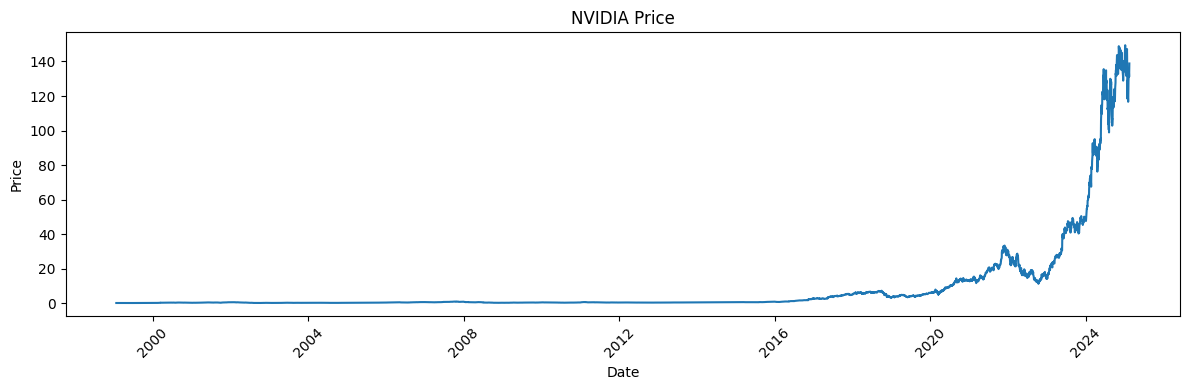

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["Adj Close"])
plt.title("NVIDIA Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


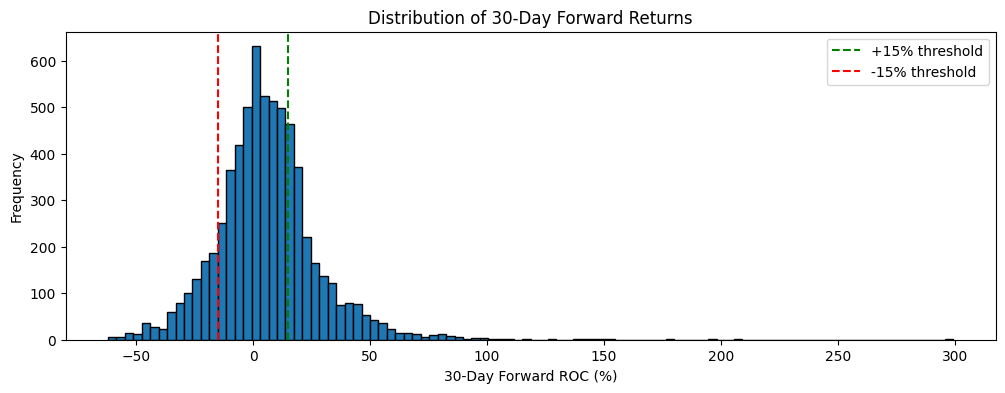

In [4]:
# Compute 30-day forward ROC
horizon = 30
df["roc_30d"] = ((df["Adj Close"].shift(-horizon) - df["Adj Close"]) / df["Adj Close"]) * 100

# Drop last 30 rows (no future data)
df = df.iloc[:-horizon]

# Distribution of forward returns
plt.figure(figsize=(12, 4))
plt.hist(df["roc_30d"].dropna(), bins=100, edgecolor="black")
plt.xlabel("30-Day Forward ROC (%)")
plt.ylabel("Frequency")
plt.title("Distribution of 30-Day Forward Returns")
plt.axvline(x=15,  color="green", linestyle="--", label="+15% threshold")
plt.axvline(x=-15, color="red",   linestyle="--", label="-15% threshold")
plt.legend()
plt.show()


In [5]:
# Label extreme events — 3 classes
# 0 = Extreme DOWN  (roc < -15%)
# 1 = Normal        (-15% <= roc <= 15%)
# 2 = Extreme UP    (roc > 15%)

def assign_label(r):
    if r > 15:    return 2
    elif r < -15: return 0
    else:         return 1

df["target"] = df["roc_30d"].apply(assign_label)

print("Label distribution:")
print(df["target"].value_counts().sort_index())
print()
print(df["target"].value_counts(normalize=True).sort_index().round(3))


Label distribution:
target
0     858
1    3839
2    1831
Name: count, dtype: int64

target
0    0.131
1    0.588
2    0.280
Name: proportion, dtype: float64


In [6]:
# Event statistics
def event_statistics(roc_series, threshold):
    up   = (roc_series > threshold).sum()
    down = (roc_series < -threshold).sum()
    total = len(roc_series.dropna())
    print(f"Threshold       : ±{threshold}%")
    print(f"Extreme UP      : {up}  ({up/total:.1%})")
    print(f"Extreme DOWN    : {down}  ({down/total:.1%})")
    print(f"Normal          : {total - up - down}  ({(total-up-down)/total:.1%})")
    print(f"Event frequency : {(up+down)/total:.1%}")

event_statistics(df["roc_30d"], 15)


Threshold       : ±15%
Extreme UP      : 1831  (28.0%)
Extreme DOWN    : 858  (13.1%)
Normal          : 3839  (58.8%)
Event frequency : 41.2%


In [7]:
# ===== TREND INDICATORS =====
df["ema_20"] = ta.trend.EMAIndicator(df["Adj Close"], window=20).ema_indicator()
df["ema_50"] = ta.trend.EMAIndicator(df["Adj Close"], window=50).ema_indicator()
df["ema_ratio_20_50"] = df["ema_20"] / df["ema_50"]
df["price_to_ema20"]  = df["Adj Close"] / df["ema_20"]

# ===== MOMENTUM INDICATORS =====
df["rsi_14"]  = ta.momentum.RSIIndicator(df["Adj Close"], window=14).rsi()
stoch = ta.momentum.StochasticOscillator(df["High"], df["Low"], df["Adj Close"], window=14, smooth_window=3)
df["stoch_k"] = stoch.stoch()
df["roc_10"]  = ta.momentum.ROCIndicator(df["Adj Close"], window=10).roc()

# ===== VOLATILITY INDICATORS =====
df["volatility_20"] = df["Adj Close"].pct_change().rolling(window=20).std() * 100
atr = ta.volatility.AverageTrueRange(df["High"], df["Low"], df["Adj Close"], window=14)
df["atr_ratio"] = (atr.average_true_range() / df["Adj Close"]) * 100

bb = ta.volatility.BollingerBands(df["Adj Close"], window=20)
df["bb_position"] = (df["Adj Close"] - bb.bollinger_lband()) / (bb.bollinger_hband() - bb.bollinger_lband())

# ===== VOLUME INDICATORS =====
obv = ta.volume.OnBalanceVolumeIndicator(df["Adj Close"], df["Volume"])
df["obv_change"]    = obv.on_balance_volume().pct_change() * 100
df["volume_zscore"] = (df["Volume"] - df["Volume"].rolling(20).mean()) / df["Volume"].rolling(20).std()

# ===== CUSTOM FEATURES =====
df["return_5d"]            = df["Adj Close"].pct_change(5) * 100
df["momentum_acc"]         = df["Adj Close"].pct_change(5) - df["Adj Close"].pct_change(10)
df["trend_consistency_10"] = df["Adj Close"].pct_change().rolling(10).apply(lambda x: (x > 0).mean())
df["vol_regime"]           = (df["volatility_20"] > df["volatility_20"].rolling(50).mean()).astype(int)

df = df.dropna().reset_index(drop=True)
print(f"Dataset size after feature engineering: {len(df)} rows")


Dataset size after feature engineering: 6479 rows


In [8]:
selected_features = [
    "ema_ratio_20_50", "price_to_ema20",
    "rsi_14", "stoch_k", "roc_10",
    "volatility_20", "atr_ratio",
    "bb_position", "volume_zscore",
    "obv_change", "return_5d",
    "momentum_acc", "trend_consistency_10", "vol_regime"
]

X = df[selected_features]
y = df["target"]

print(X.describe().round(3))


       ema_ratio_20_50  price_to_ema20    rsi_14   stoch_k    roc_10  \
count         6479.000        6479.000  6479.000  6479.000  6479.000   
mean             1.015           1.012    53.656    21.349     1.969   
std              0.070           0.079    12.883    43.848    12.059   
min              0.660           0.557    13.025  -148.177   -50.260   
25%              0.986           0.972    44.428   -10.010    -4.548   
50%              1.021           1.015    53.975    21.870     1.616   
75%              1.059           1.055    62.770    55.862     7.853   
max              1.302           1.915    91.421    99.965   145.678   

       volatility_20  atr_ratio  bb_position  volume_zscore  obv_change  \
count       6479.000   6479.000     6479.000       6479.000    6479.000   
mean           3.292      8.681        0.563         -0.004       0.026   
std            1.855      4.270        0.333          1.047      16.397   
min            0.563      2.044       -0.479       

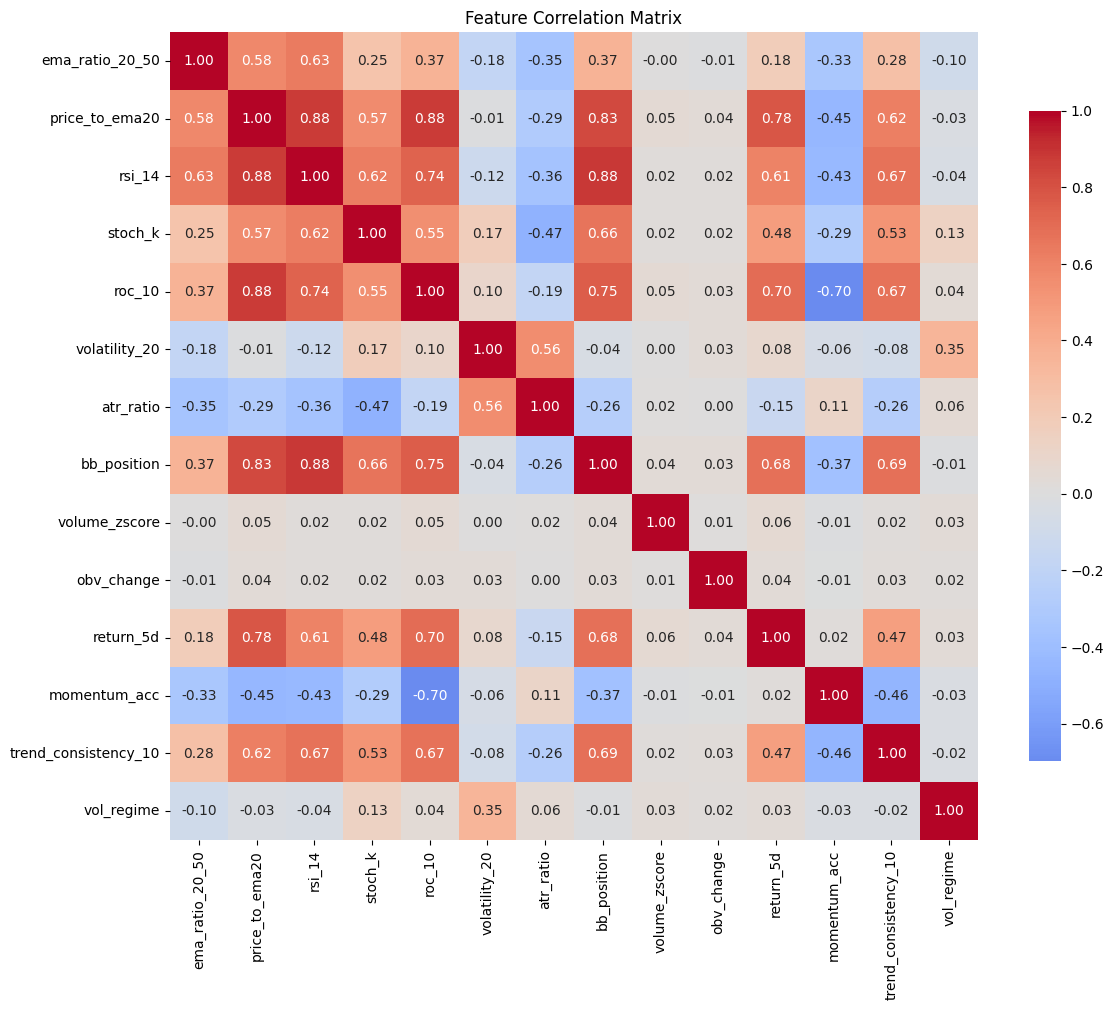

In [9]:
# Feature correlation matrix
corr = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [10]:
# Correlation of each feature with target
target_corr = pd.concat([X, y], axis=1).corr()["target"].drop("target").sort_values()
print("Feature — Target Correlation:")
print(target_corr.round(3))


Feature — Target Correlation:
vol_regime             -0.095
atr_ratio              -0.081
momentum_acc           -0.017
volume_zscore          -0.012
obv_change             -0.010
volatility_20          -0.007
return_5d              -0.002
roc_10                  0.010
bb_position             0.015
price_to_ema20          0.023
rsi_14                  0.037
trend_consistency_10    0.041
ema_ratio_20_50         0.046
stoch_k                 0.063
Name: target, dtype: float64


In [11]:
# Time-based split: 80% train, 20% test (no shuffle — avoids data leakage)
split = int(len(X) * 0.80)

X_train = X.iloc[:split].reset_index(drop=True)
X_test  = X.iloc[split:].reset_index(drop=True)
y_train = y.iloc[:split].reset_index(drop=True)
y_test  = y.iloc[split:].reset_index(drop=True)
dates_test = df["Date"].iloc[split:].reset_index(drop=True)
close_test = df["Adj Close"].iloc[split:].reset_index(drop=True)

print(f"Train: {len(X_train)} samples")
print(f"Test : {len(X_test)}  samples")
print()
print("Train label distribution:")
print(y_train.value_counts().sort_index())


Train: 5183 samples
Test : 1296  samples

Train label distribution:
target
0     748
1    3045
2    1390
Name: count, dtype: int64


Before SMOTE: {0: 748, 1: 3045, 2: 1390}
After  SMOTE: {0: 3045, 1: 3045, 2: 3045}


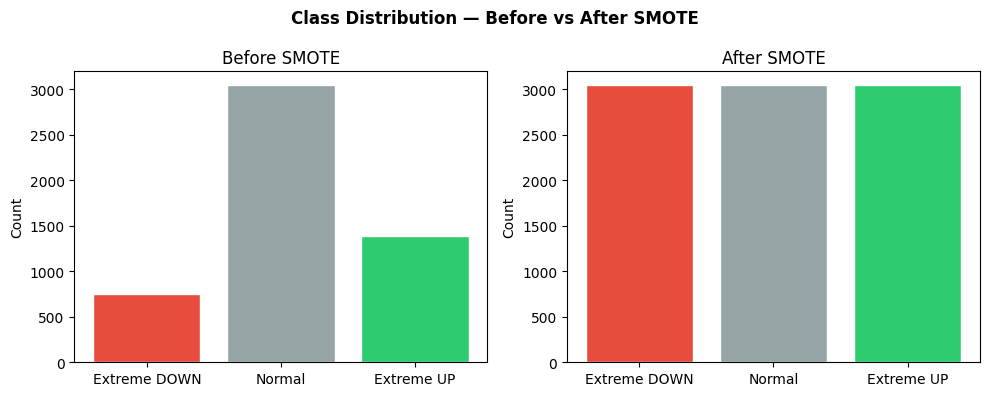

In [12]:
# SMOTE — oversample minority classes in training set only
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().sort_index().to_dict())
print("After  SMOTE:", pd.Series(y_res).value_counts().sort_index().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
label_map = {0: "Extreme DOWN", 1: "Normal", 2: "Extreme UP"}
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]

before = y_train.value_counts().sort_index()
after  = pd.Series(y_res).value_counts().sort_index()

axes[0].bar([label_map[k] for k in sorted(before.index)], before.values, color=colors, edgecolor="white")
axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Count")

axes[1].bar([label_map[k] for k in sorted(after.index)], after.values, color=colors, edgecolor="white")
axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Count")

plt.suptitle("Class Distribution — Before vs After SMOTE", fontweight="bold")
plt.tight_layout()
plt.show()


In [13]:
#XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.3,
    reg_lambda=1.5,
    eval_metric="mlogloss",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_res, y_res,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"Best iteration: {xgb_model.best_iteration}")
print(f"Trees used    : {xgb_model.best_iteration + 1}")


Best iteration: 48
Trees used    : 49


In [14]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)

print(classification_report(y_test, y_pred, target_names=["Extreme DOWN", "Normal", "Extreme UP"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

Extreme DOWN       0.13      0.22      0.16       106
      Normal       0.59      0.63      0.61       750
  Extreme UP       0.33      0.24      0.28       440

    accuracy                           0.46      1296
   macro avg       0.35      0.36      0.35      1296
weighted avg       0.46      0.46      0.46      1296

Confusion Matrix:
[[ 23  65  18]
 [ 86 471 193]
 [ 74 262 104]]


In [15]:
# ROC-AUC
y_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_macro    = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
roc_weighted = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="weighted")
print(f"ROC-AUC (macro)    : {roc_macro:.4f}")
print(f"ROC-AUC (weighted) : {roc_weighted:.4f}")


ROC-AUC (macro)    : 0.5246
ROC-AUC (weighted) : 0.5310


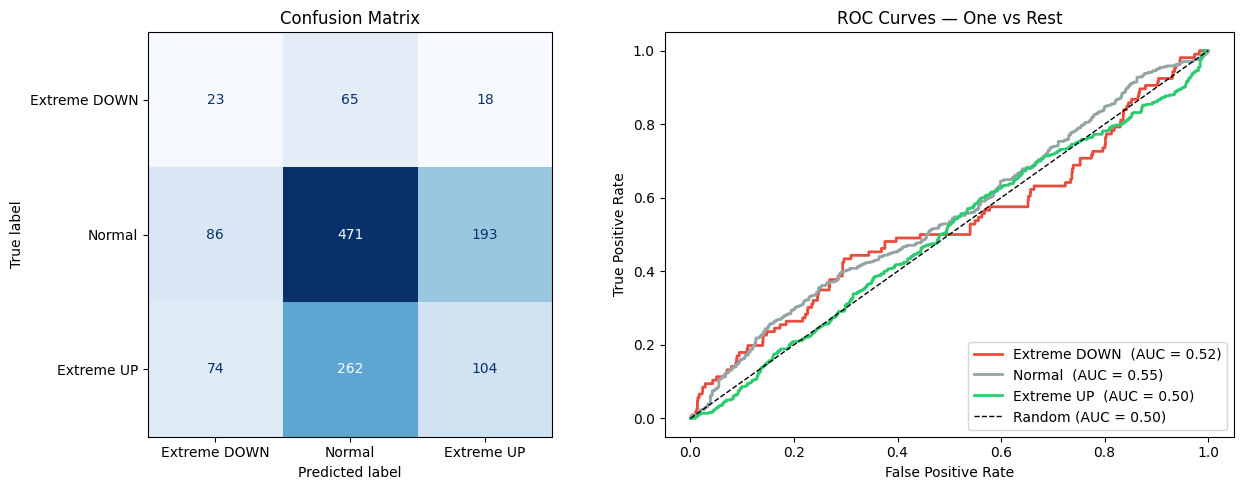

In [16]:
# Confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Extreme DOWN", "Normal", "Extreme UP"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC curves
class_names = ["Extreme DOWN", "Normal", "Extreme UP"]
roc_colors  = ["#e74c3c", "#95a5a6", "#2ecc71"]
for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=roc_colors[i], lw=2, label=f"{class_names[i]}  (AUC = {roc_val:.2f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.50)")
axes[1].set_title("ROC Curves — One vs Rest")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


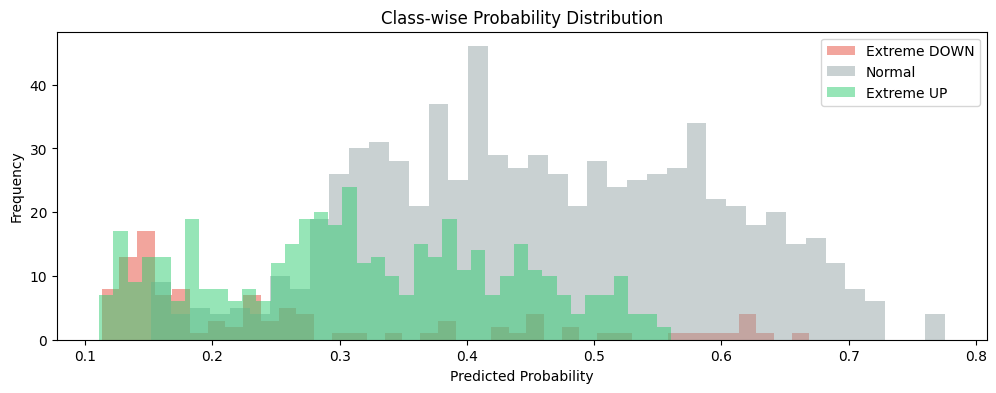

In [17]:
# Class-wise probability distribution
plt.figure(figsize=(12, 4))
for i, (cls, col) in enumerate(zip(["Extreme DOWN", "Normal", "Extreme UP"], ["#e74c3c", "#95a5a6", "#2ecc71"])):
    plt.hist(y_prob[y_test == i, i], bins=40, alpha=0.5, label=cls, color=col)
plt.legend()
plt.title("Class-wise Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()


atr_ratio               0.136302
trend_consistency_10    0.118470
vol_regime              0.102181
volatility_20           0.097427
price_to_ema20          0.079520
roc_10                  0.075094
ema_ratio_20_50         0.071313
stoch_k                 0.066348
obv_change              0.048151
rsi_14                  0.046550
return_5d               0.043681
momentum_acc            0.040915
bb_position             0.040733
volume_zscore           0.033314
dtype: float32


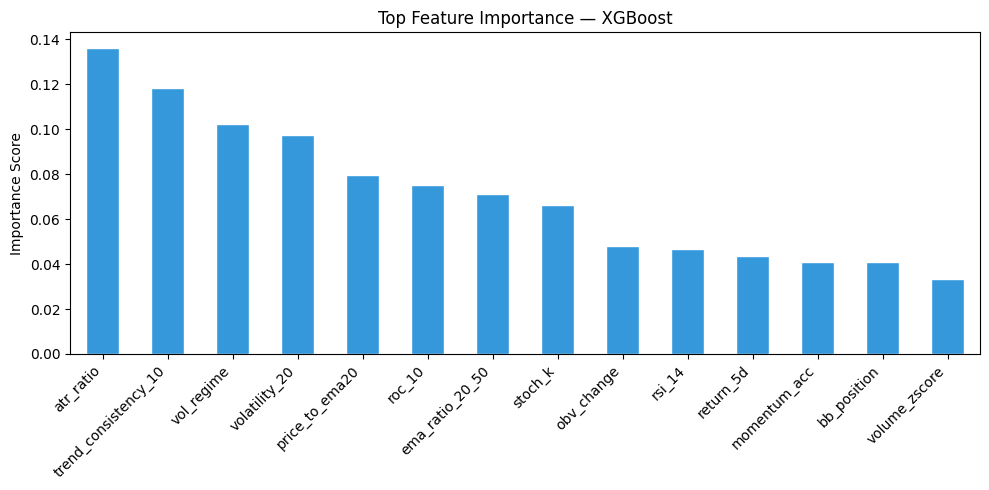

In [18]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

print(importance.head(15))

importance.head(15).plot(kind="bar", color="#3498db", edgecolor="white", figsize=(10, 5))
plt.title("Top Feature Importance — XGBoost")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


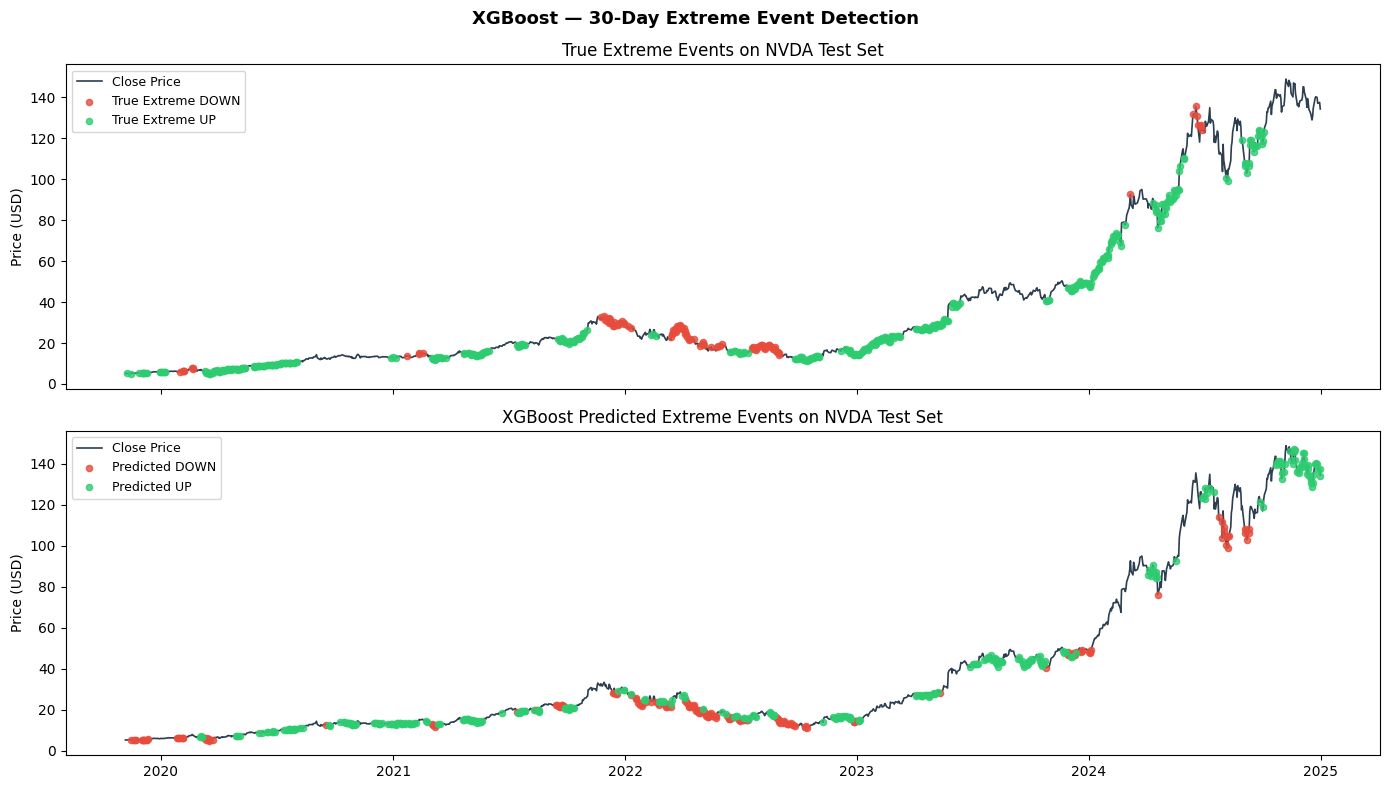

In [19]:
# XGBoost predictions on test set price
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

pred_arr  = np.array(y_pred)
true_arr  = np.array(y_test)
close_arr = close_test.values
dates_arr = dates_test.values

# Panel 1: True labels
ax = axes[0]
ax.plot(dates_arr, close_arr, color="#2c3e50", lw=1.2, label="Close Price")
for label_id, col, name in [(0, "#e74c3c", "Extreme DOWN"), (2, "#2ecc71", "Extreme UP")]:
    mask = true_arr == label_id
    ax.scatter(dates_arr[mask], close_arr[mask], color=col, s=20, zorder=5, alpha=0.8, label=f"True {name}")
ax.set_title("True Extreme Events on NVDA Test Set")
ax.set_ylabel("Price (USD)")
ax.legend(fontsize=9)

# Panel 2: Predicted labels
ax = axes[1]
ax.plot(dates_arr, close_arr, color="#2c3e50", lw=1.2, label="Close Price")
for label_id, col, name in [(0, "#e74c3c", "Predicted DOWN"), (2, "#2ecc71", "Predicted UP")]:
    mask = pred_arr == label_id
    ax.scatter(dates_arr[mask], close_arr[mask], color=col, s=20, zorder=5, alpha=0.8, label=name)
ax.set_title("XGBoost Predicted Extreme Events on NVDA Test Set")
ax.set_ylabel("Price (USD)")
ax.legend(fontsize=9)

plt.suptitle("XGBoost — 30-Day Extreme Event Detection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
